### **Breast Cancer Prediction using Neural Network | Deep Learning Project - Python & TensorFlow / Keras**

-> Malignant = Cancerous tumor (can spread)

-> Benign = Non-Cancerous tumor (can't spread)

### ***1. Import & Setup***

In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

print("TensorFlow", tf.__version__)

TensorFlow 2.20.0


In [244]:
# set seeds for reproducible results
np.random.seed(42)
tf.random.set_seed(42)

# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f' {x:.4f}')

### ***2. Load Dataset***

In [245]:
# Upload the dataset and load and in df
df = pd.read_csv("breast_cancer_dataset.csv")

### ***3. Quick Exploration***

In [246]:
df.shape

(569, 33)

In [247]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,NaN
1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,NaN
2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,NaN
3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,NaN
4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,NaN


In [248]:
# drop "id" and "Unnamed: 32" columns
df = df.drop(columns=["id", "Unnamed: 32"])

In [249]:
# convert label to 0 and 1
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1}).astype(int)

In [250]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,1,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,1,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,1,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [251]:
class_names = ["Benign", "Malignant"]

In [252]:
df.shape

(569, 31)

In [253]:
# check target distribution
df["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


In [254]:
# check target distribution in %
df["diagnosis"].value_counts(normalize=True)*100

,proportion
diagnosis,
0,62.7417
1,37.2583


Need sampling? Not strictly. A 62/37 split isn’t extreme like 90/10.


In [255]:
# Returns True if there are missing values anywhere in the DataFrame.
df.isnull().values.any()

np.False_

In [256]:
# checking number of outliers in each column using IQR method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
outliers.sum()


,0
diagnosis,0
radius_mean,14
texture_mean,7
perimeter_mean,13
area_mean,25
smoothness_mean,6
compactness_mean,16
concavity_mean,18
concave points_mean,10
symmetry_mean,15


In [257]:
# descriptive stats for specific columns
df[["radius_mean", "area_mean", "smoothness_mean"]].describe()

,radius_mean,area_mean,smoothness_mean
count,569.0000,569.0000,569.0000
mean,14.1273,654.8891,0.0964
std,3.5240,351.9141,0.0141
min,6.9810,143.5000,0.0526
25%,11.7000,420.3000,0.0864
50%,13.3700,551.1000,0.0959
75%,15.7800,782.7000,0.1053
max,28.1100,2501.0000,0.1634


### ***4. Train/Val/Test Split***

In [258]:
# split the df into feature(X) and target(y)
X = df.drop(columns=["diagnosis"])
y= df["diagnosis"]

In [259]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [260]:
y.head()

,diagnosis
0,1
1,1
2,1
3,1
4,1


In [261]:
# first peel of the test set (20%)
X_train_full, X_test, y_train_full, y_test=train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# then split the remaining X_train_full into train(60%) and validation(20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

print("X_train shape", X_train.shape)
print("X_val shape", X_val.shape)
print("X_test shape", X_test.shape)

X_train shape (341, 30)
X_val shape (114, 30)
X_test shape (114, 30)


Train the model with X_train and y_train

- This is the actual learning phase.

- The model sees the training data and adjusts its weights to minimize loss.

Validate the model with X_val and y_val

- After each epoch (or at checkpoints), the model is evaluated on the validation set.

- These samples are not used for training updates — they only measure how well the model generalizes.

- Helps you tune hyperparameters and detect overfitting.

Test the model with X_test and y_test

- Once training is complete, you evaluate on the test set.

- This set was never touched during training or validation.

- It gives us an unbiased estimate of how the model will perform on new, unseen data.

### ***5. Scalen the features***

StandardScaler centers around the mean and scales by the standard deviation

$$
x' = \frac{x - \text{mean}(x)}{\text{std}(x)}
$$


NOTE:- *Fit scaler on train only - Scaling before splitting would leak test‑set statistics into training (data leakage).*

In [262]:
scaler = StandardScaler()

In [263]:
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

NOTE: *use transform (not fit_transform) on validation and test sets — they must be scaled with the training set’s median/IQR. Refitting on val/test would give each set its own scaling, breaking comparability and leaking their statistics.*

### ***6. Build the Model***

A small fully connected network.
- **ReLU** in the hidden layers
- **sigmoid** in the output - it squashes to a value in (0, 1) we read as
  *"probability of malignant"* (our positive class), which is exactly what
  binary classification needs.

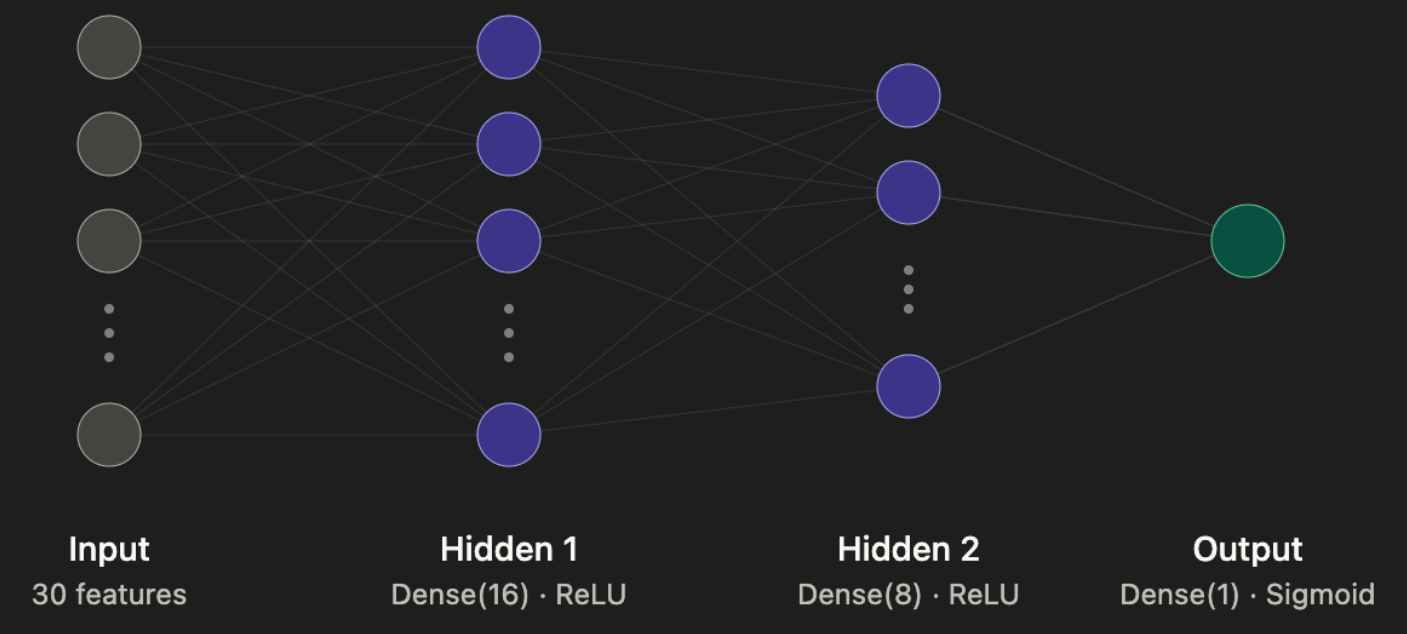

In [264]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),     # Input layer    : 30 features
    keras.layers.Dense(16, activation="relu"),  # Hideen layer 1 : relu
    keras.layers.Dense(8, activation="relu"),   # Hidden layer 2 : relu
    keras.layers.Dense(1, activation="sigmoid") # Output layer: sigmoid- outputs a probability between 0 and 1 (malignant vs benign)
])

In [265]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [266]:
# compile the model - it tells the framework how the model should learn.
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

### ***7. Training the Model***

**Early stopping** *watches the validation loss and halts when it stops improving,
then restores the best weights. This is our first line of defense against overfitting.*

In [267]:
early_stop = keras.callbacks.EarlyStopping(
    monitor = "val_loss", patience = 10, restore_best_weights = True
)

In [268]:
class PrintEvery10(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if (epoch + 1) % 10 == 0:
            print(f"epoch {epoch + 1:3d}  "
                  f"loss {logs['loss']:.4f}  acc {logs['accuracy']:.4f}  "
                  f"val_loss {logs['val_loss']:.4f}  val_acc {logs['val_accuracy']:.4f}")

In [269]:
# Training Model
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 32,
    callbacks = [early_stop, PrintEvery10()],
    verbose = 0
)

epoch  10  loss 0.1396  acc 0.9648  val_loss 0.1401  val_acc 0.9737
epoch  20  loss 0.0766  acc 0.9853  val_loss 0.0966  val_acc 0.9649
epoch  30  loss 0.0538  acc 0.9912  val_loss 0.0798  val_acc 0.9649
epoch  40  loss 0.0407  acc 0.9912  val_loss 0.0724  val_acc 0.9649
epoch  50  loss 0.0306  acc 0.9941  val_loss 0.0671  val_acc 0.9649
epoch  60  loss 0.0235  acc 0.9941  val_loss 0.0647  val_acc 0.9649
epoch  70  loss 0.0178  acc 0.9941  val_loss 0.0633  val_acc 0.9649
epoch  80  loss 0.0135  acc 1.0000  val_loss 0.0622  val_acc 0.9649
epoch  90  loss 0.0102  acc 1.0000  val_loss 0.0612  val_acc 0.9649
epoch 100  loss 0.0078  acc 1.0000  val_loss 0.0597  val_acc 0.9649


***training loss/accuracy** = how well the model learns; **validation loss/accuracy** = how well it generalizes. Both are essential for monitoring.*

In [270]:
print("Trained for", len(history.history["loss"]))

Trained for 100


### ***8. Learning Curves***

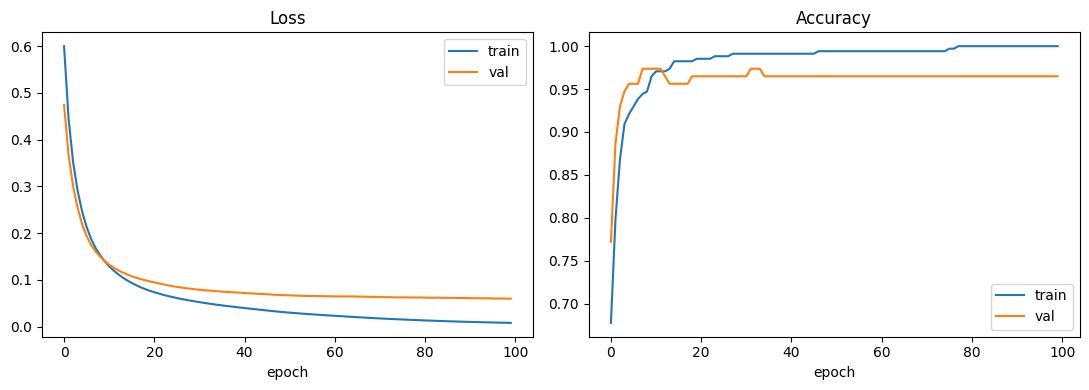

In [271]:
hist = history.history

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist["accuracy"], label="train")
plt.plot(hist["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()

plt.tight_layout()
plt.show()

### ***9. Evaluate on the test set***

>*Note: This is the first and only time we use the test set.*

In [272]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", round(test_loss, 3))
print("Test accuracy:", round(test_acc, 3))

Test loss: 0.137
Test accuracy: 0.965


In [273]:
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("First 5 probabilities:", y_prob[:5].round(3))
print("First 5 predictions:  ", y_pred[:5])

First 5 probabilities: [0.    1.    0.001 0.891 0.93 ]
First 5 predictions:   [0 1 0 1 1]


### ***10. Confusion Matrix***

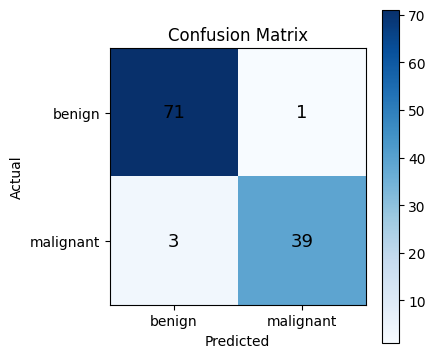

In [274]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0, 1], ["benign", "malignant"])
plt.yticks([0, 1], ["benign", "malignant"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
plt.colorbar()
plt.tight_layout()
plt.show()

### ***11. Precision, recall, F1***

In [275]:
print(classification_report(y_test, y_pred, target_names = class_names))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### ***12. ROC curve & AUC***

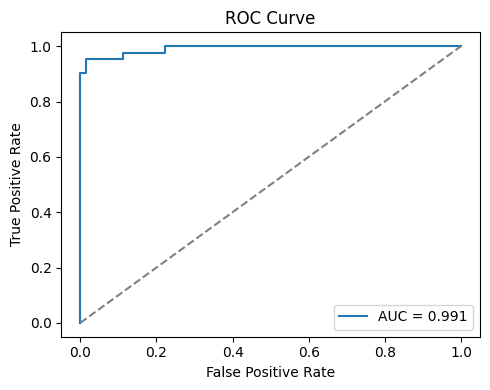

In [276]:
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend()
plt.tight_layout()
plt.show()

### ***13. Save the model & the scaler***

In [277]:
import joblib

# save the model
model.save("breast_cancer_model.keras")

# saving the scaler
joblib.dump(scaler, "scaler.joblib")

print("Saved: breast_cancer_model.keras, scaler.joblib")



Saved: breast_cancer_model.keras, scaler.joblib
